# Linear Algebra Practice

In [2]:
import numpy as np
import matplotlib.pyplot as plt

### Column space, null space, rank

In [3]:
def generate_rank_matrix(m, n, r, seed=None):
    rng = np.random.default_rng(seed)
    while True:
        U = rng.normal(size=(m, r)) * rng.integers(1, 4)
        V = rng.normal(size=(r, n)) * rng.integers(1,4)
        A = U @ V
        if np.linalg.matrix_rank(A) == r:
            return A
A = generate_rank_matrix(3,2,2)

In [4]:
def rref(A, tol=1e-12, ignore_last=False):
    pivots = []
    row = 0
    for c in range(len(A[0])):
        #check which column has the pivot
        if c == len(A[0])-1 and ignore_last:
            continue
        pivot = None
        for r in range(row, len(A)):
            if abs(A[r, c]) > tol:
                pivot = r
                break
        if pivot is None:
            continue
        if pivot != row:
            A[[r, pivot]] = A[[pivot, r]]
        A[r] = A[r] / A[r][c]
        for r in range(len(A)):
            if r != row:
                A[r] -= A[row] * A[r][c]
        pivots.append(row)
        row += 1
        if row == len(A[0]):
            break
    A[abs(A) < tol] = 0.0
    return A, pivots


R, pivots = rref(A.copy())                

In [5]:
def build_nullspace(R, pivots, tol=1e-12):
    R = R.astype(float)
    m, n = R.shape
    pivots = list(pivots)
    free_cols = [j for j in range(n) if j not in pivots]
    r = len(pivots)
    f = len(free_cols)

    if f == 0:
        return np.zeros((n, 0))  # empty basis

    N = np.zeros((n, f))
    for k, free_j in enumerate(free_cols):
        x = np.zeros(n)
        x[free_j] = 1.0
        for i, pivot_j in enumerate(pivots):
            x[pivot_j] = -R[i, free_j]
        N[:, k] = x

    N[np.abs(N) < tol] = 0.0
    return N


N = build_nullspace(A.copy(), pivots)
print(N)

[]


In [6]:
def column_basis(A, pivots):
    return A[:, pivots]
column_basis(A.copy(), pivots)

array([[ 2.33415562, -6.8732379 ],
       [ 0.89502455, -3.01689215],
       [ 0.14351732, -0.49738533]])

In [7]:
def compute_solution(A, b, tol=1e-12):
    m, n = A.shape
    Aug = np.column_stack([A.astype(float), b.astype(float)])
    R_aug, pivots = rref(Aug, tol, True)  
    R = R_aug[:, :n]
    rhs = R_aug[:, n]

    for i in range(m):
        if np.all(np.abs(R[i]) < tol) and abs(rhs[i]) > tol:
            return np.zeros((n, 0)), "none"

    N = build_nullspace(R, pivots, tol)  
    x_p = np.zeros(n)
    for i, pcol in enumerate(pivots):
        if pcol < n:         
            x_p[pcol] = rhs[i]

    if N.shape[1] == 0:
        return x_p, "unique"
    else:
        full = np.column_stack([x_p, N])  
        return full, "infinite"
b = np.sum(column_basis(A.copy(), pivots), axis=1)
compute_solution(A.copy(), b)

(array([1., 1.]), 'unique')

### Projections

In [8]:
def compute_projections(a, b):
    numerator = np.dot(a.T, b)
    denominator = np.dot(a.T, a)
    x = numerator/denominator
    p = a * x
    return p
a = np.random.uniform(0, 10, size=3)
b = np.random.uniform(0, 10, size=3)
p = compute_projections(a,b)
ortho = np.dot((b-p), a)
print(p, ortho.round(10))

[3.13354374 3.49769107 4.17703884] -0.0


In [9]:
def compute_projection_matrix(A):
    _, pivots = rref(A.copy())
    A = A[:, pivots]
    inverse = np.linalg.inv(A.T @ A)
    P = A @ inverse @ A.T
    P[np.abs(P) < 1e-12] = 0.0
    return P

b = np.random.uniform(0, 10, size=A.shape[0])
P = compute_projection_matrix(A.copy())
projection = P @ b
print("Projection matrix P:")
print(P)
print("\nProjection of b onto column space of A:")
print(projection)
# Verify idempotent property of projection matrix
print("P @ P == P:", np.allclose(P @ P, P))

# Check orthogonality: A^T * (projection - b) should be zero
orthogonal_check = A.T @ (projection - b)
print("\nA^T * (projection - b):")
print(orthogonal_check)
print("Is orthogonal (close to zero):", np.allclose(orthogonal_check, 0))

Projection matrix P:
[[ 0.99981928  0.00258645 -0.01319078]
 [ 0.00258645  0.96298288  0.18878602]
 [-0.01319078  0.18878602  0.03719784]]

Projection of b onto column space of A:
[8.99914943 1.65175391 0.20058349]
P @ P == P: True

A^T * (projection - b):
[-8.09352585e-13  2.44249065e-12]
Is orthogonal (close to zero): True


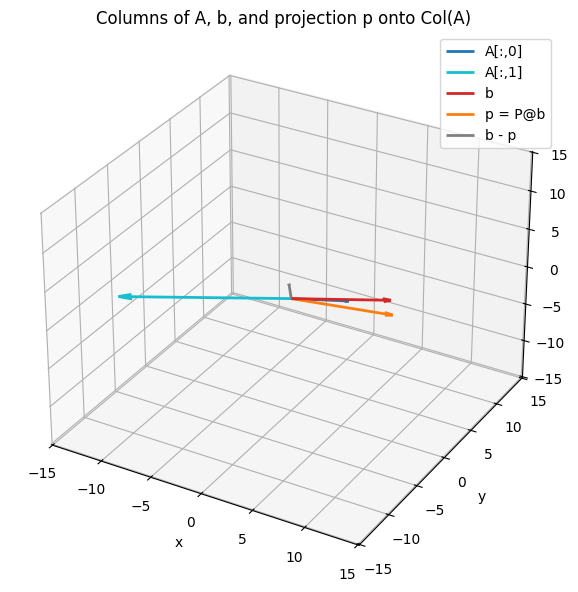

In [10]:

# Columns of A (each is a vector in R^3)
a_cols = [A[:, j] for j in range(A.shape[1])]

# b and its projection p onto Col(A)
p = projection  # or: p = P @ b

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

def draw_vec(v, color, label):
    ax.quiver(0, 0, 0, v[0], v[1], v[2],
              color=color, arrow_length_ratio=0.08, linewidth=2, label=label)

a_cols = [v * 2 for v in a_cols]
colors = ["tab:blue", "tab:cyan", "tab:purple", "tab:green"]
for j, v in enumerate(a_cols):
    draw_vec(v, colors[j % len(colors)], f"A[:,{j}]")

# draw b, projection p, and the residual (b - p)
draw_vec(b, "tab:red", "b")
draw_vec(p, "tab:orange", "p = P@b")
draw_vec(b - p, "tab:gray", "b - p")

# Set axis limits nicely
all_vecs = np.column_stack(a_cols + [b, p, b - p])
m = np.max(np.abs(all_vecs))
lim = 1.1 * (m if m > 0 else 1.0)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)

ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title("Columns of A, b, and projection p onto Col(A)")
ax.legend()
plt.tight_layout()
plt.show()

### Least Squares

In [11]:
def least_squares(A, b):
    b_hat = A.T @ b
    A_square = A.T @ A
    sol, status = compute_solution(A_square, b_hat)
    if status == "none":
        raise ValueError("Normal equations reported inconsistent (should not happen in exact arithmetic).")
    if status == "unique":
        x_hat = sol
    else: 
        x_hat = sol[:, 0] 
    return x_hat
# Generate a new overdetermined system for least squares (e.g., 4 equations, 2 variables)
new_A = generate_rank_matrix(4, 1, 1, seed=42)
new_A = np.column_stack([np.ones(4), new_A])
new_b = np.random.uniform(0, 10, size=4)

# Compute least squares solution
x_hat = least_squares(new_A, new_b)
print("Least squares solution x_hat:")
print(x_hat)
p = new_A @ x_hat
print(f"Projection of b on to Col(A): {p}")
e = new_b - p
ortho = new_A.T @ e
print("Ortho:", ortho)
print("Is ortho close to zero:", np.allclose(ortho, 0))

Least squares solution x_hat:
[ 6.97107337 -1.27981728]
Projection of b on to Col(A): [7.47890018 5.23788595 8.22173919 8.53857322]
Ortho: [ 8.8817842e-16 -4.4408921e-16]
Is ortho close to zero: True


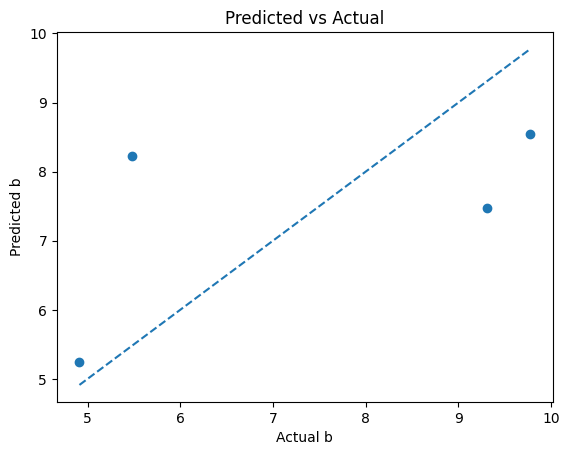

In [12]:
b_pred = new_A @ x_hat
plt.scatter(new_b, b_pred)
plt.xlabel("Actual b")
plt.ylabel("Predicted b")
plt.title("Predicted vs Actual")
plt.plot([new_b.min(), new_b.max()], [new_b.min(), new_b.max()], '--')  # y=x reference
plt.show()

### Eigenvectors and Eigenvalues

In [13]:
A = np.array([[2, 1],
              [1, 1]], float)
x0 = np.array([0, 1])
steps = 1000
angles = []
estimates = []
y = x0
for i in range(steps):
    y = A@y
    y = y / np.linalg.norm(y)
    angle = np.arctan2(y[1], y[0])
    angles.append(angle)
    lambda_k = (y @ (A @ y)) / (y @ y) 
    estimates.append(lambda_k)

In [14]:
lambda_true = max(np.linalg.eig(A)[0])
x_true = np.linalg.eig(A)[1]

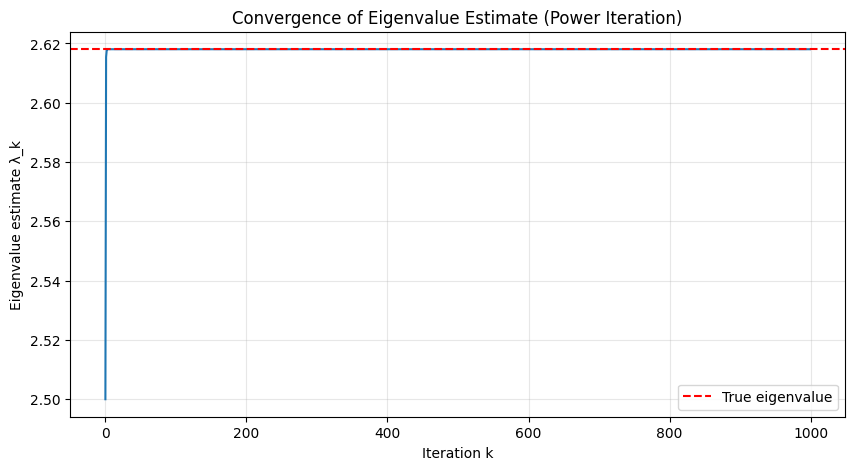

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(range(steps), estimates)
plt.xlabel('Iteration k')
plt.ylabel('Eigenvalue estimate λ_k')
plt.title('Convergence of Eigenvalue Estimate (Power Iteration)')
plt.grid(True, alpha=0.3)
plt.axhline(y=lambda_true, color='r', linestyle='--', label='True eigenvalue')
plt.legend()
plt.show()


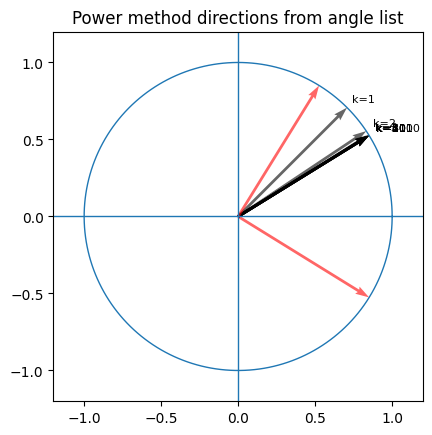

In [16]:

angles_arr = np.array(angles)          # shape (steps,)
U = np.cos(angles_arr)                 # x-components
V = np.sin(angles_arr)                 # y-components

# pick a few angles to draw
idxs = [0, 1, 2, 3, 5, 10, 20, 50, 100, 300, 999]
idxs = [i for i in idxs if i < len(angles_arr)]

# unit circle for reference
t = np.linspace(0, 2*np.pi, 400)
plt.plot(np.cos(t), np.sin(t), linewidth=1)

for i in idxs:
    plt.quiver(0, 0, U[i], V[i],
               angles='xy', scale_units='xy', scale=1, alpha=0.6)
    plt.text(U[i]*1.05, V[i]*1.05, f"k={i+1}", fontsize=8)
plt.quiver([0, 0], 0, x_true[:, 0], x_true[:, 1],
               angles='xy', scale_units='xy', scale=1, alpha=0.6, color="red")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.title("Power method directions from angle list")
plt.show()

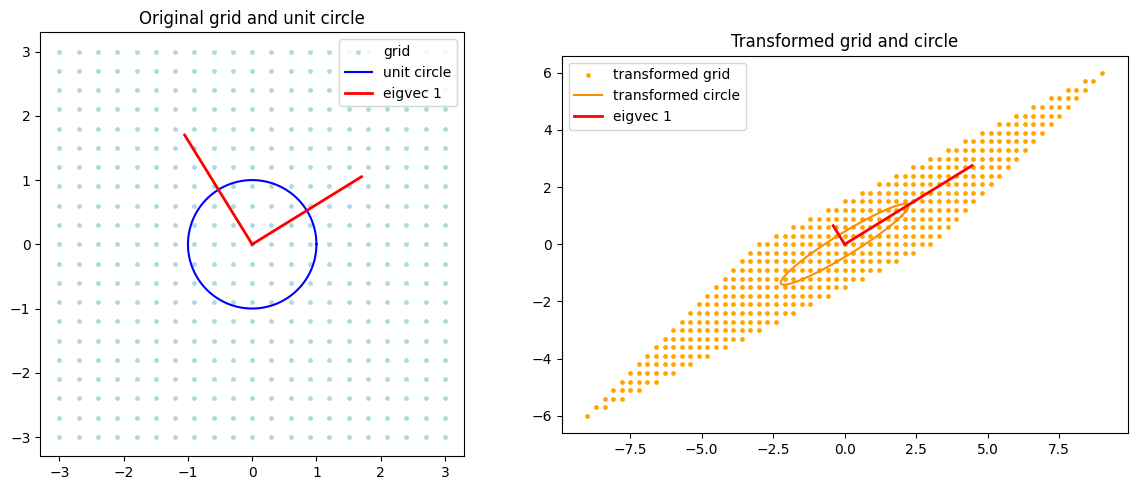

In [17]:
# 1) make a grid of points and unit circle
grid_n = 21
lims = (-3, 3)
xs = np.linspace(lims[0], lims[1], grid_n)
ys = np.linspace(lims[0], lims[1], grid_n)
xx, yy = np.meshgrid(xs, ys)
pts = np.vstack([xx.ravel(), yy.ravel()]).T

t = np.linspace(0, 2*np.pi, 300)
circle = np.vstack([np.cos(t), np.sin(t)]).T

# 2) apply A to every point and the circle
A_pts = (A @ pts.T).T
A_circle = (A @ circle.T).T

# 3) compute eigenvectors with np.linalg.eig(A)
vals, vecs = np.linalg.eig(A)
vecs_unit = vecs / np.linalg.norm(vecs, axis=0)

# 4) plot original and transformed with eigenvector directions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original space
ax = axes[0]
ax.scatter(pts[:,0], pts[:,1], s=6, color='lightblue', label='grid')
ax.plot(circle[:,0], circle[:,1], color='blue', label='unit circle')
for i in range(vecs_unit.shape[1]):
    v = vecs_unit[:, i]
    ax.plot([0, v[0]*2], [0, v[1]*2], color='red', linewidth=2,
            label=f'eigvec {i+1}' if i==0 else None)
ax.set_title('Original grid and unit circle')
ax.set_aspect('equal', 'box')
ax.legend()

# Transformed space
ax = axes[1]
ax.scatter(A_pts[:,0], A_pts[:,1], s=6, color='orange', label='transformed grid')
ax.plot(A_circle[:,0], A_circle[:,1], color='darkorange', label='transformed circle')
for i in range(vecs_unit.shape[1]):
    v = vecs_unit[:, i]
    lv = vals[i]
    # A @ v = lambda * v so direction is the same; scale by eigenvalue for visibility
    ax.plot([0, v[0]*lv*2], [0, v[1]*lv*2], color='red', linewidth=2,
            label=f'eigvec {i+1}' if i==0 else None)
ax.set_title('Transformed grid and circle')
ax.set_aspect('equal', 'box')
ax.legend()

plt.tight_layout()
plt.show()

#### Eigen diagonalization

In [18]:
A = generate_rank_matrix(2, 2, 2)
w, V = np.linalg.eig(A)

# reconstruct A
A_hat = V @ np.diag(w) @ np.linalg.inv(V)
print("A_hat ≈ A:", np.allclose(A_hat, A, atol=1e-8))

# pick exponent
n = 50

# compute A^n by repeated multiplication
A_n = np.eye(2, dtype=complex)
for _ in range(n):
    A_n = A_n @ A

# compute A^n by diagonalization
A_n_hat = V @ np.diag(w**n) @ np.linalg.inv(V)

print("A^n ≈ A^n_hat:", np.allclose(A_n, A_n_hat, atol=1e-6))
print("error norm:", np.linalg.norm(A_n - A_n_hat))

A_hat ≈ A: True
A^n ≈ A^n_hat: True
error norm: 1.8190915675025546e-24


### Applied Eigenvalues + Eigenvectors

In [30]:
A = np.array([[0.92, 0.1], [0.08, 0.9]])
x, V = np.linalg.eig(A)
x0_1 = np.array([1, 0])
x0_2 = np.array([0, 1])
print("Eigenvalues:")
print(x)
print("\nEigenvectors:")
print(V)

Eigenvalues:
[1.   0.82]

Eigenvectors:
[[ 0.78086881 -0.70710678]
 [ 0.62469505  0.70710678]]


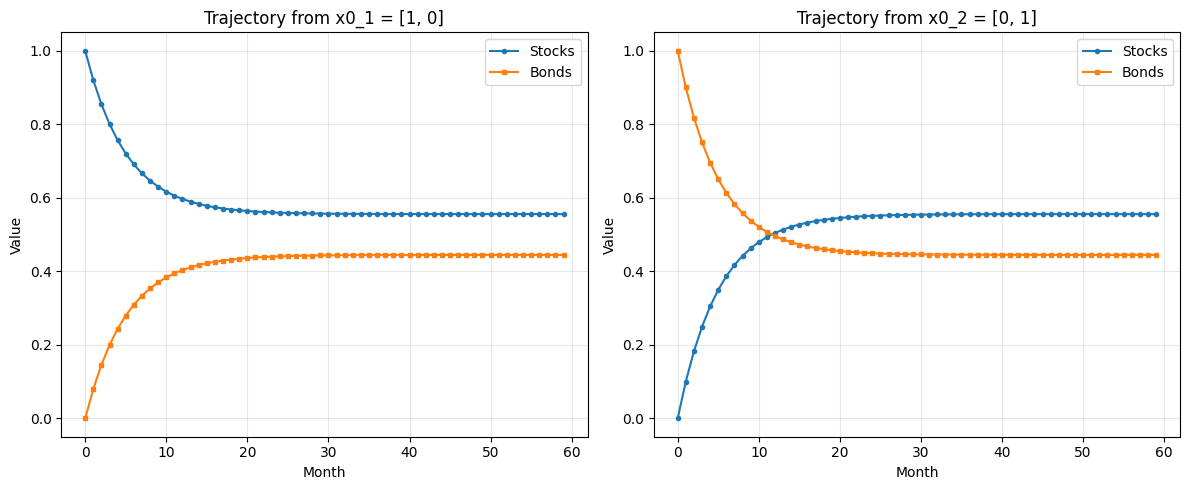

In [31]:
# Simulate x_{t+1} = A*x_t for 60 months
months = 60
trajectory_1 = np.zeros((months, 2))
trajectory_2 = np.zeros((months, 2))

x_current_1 = x0_1.copy()
x_current_2 = x0_2.copy()

for t in range(months):
    trajectory_1[t] = x_current_1
    trajectory_2[t] = x_current_2
    x_current_1 = A @ x_current_1
    x_current_2 = A @ x_current_2

# Plot both trajectories
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(trajectory_1[:, 0], label='Stocks', marker='o', markersize=3)
plt.plot(trajectory_1[:, 1], label='Bonds', marker='s', markersize=3)
plt.xlabel('Month')
plt.ylabel('Value')
plt.title('Trajectory from x0_1 = [1, 0]')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(trajectory_2[:, 0], label='Stocks', marker='o', markersize=3)
plt.plot(trajectory_2[:, 1], label='Bonds', marker='s', markersize=3)
plt.xlabel('Month')
plt.ylabel('Value')
plt.title('Trajectory from x0_2 = [0, 1]')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
def A_n(S, x, n):
    X = np.diag(x**n)
    return S @ X @ np.linalg.inv(S)
    # Using eigenvalue diagonalization from cell 24
A_60_diag = A_n(V, x, 60)

# Compute trajectories using diagonalization
x_60_1 = A_60_diag @ x0_1
x_60_2 = A_60_diag @ x0_2

print("State after 60 months from x0_1 using diagonalization:")
print(x_60_1)
print("\nState after 60 months from x0_2 using diagonalization:")
print(x_60_2)

# Compare with iterative method
print("\nComparison with iterative method:")
print("x0_1: Iterative =", trajectory_1[-1], "Diag =", x_60_1)
print("x0_2: Iterative =", trajectory_2[-1], "Diag =", x_60_2)
print("Close match:", np.allclose(trajectory_1[-1], x_60_1) and np.allclose(trajectory_2[-1], x_60_2))

State after 60 months from x0_1 using diagonalization:
[0.55555855 0.44444145]

State after 60 months from x0_2 using diagonalization:
[0.55555181 0.44444819]

Comparison with iterative method:
x0_1: Iterative = [0.55555921 0.44444079] Diag = [0.55555855 0.44444145]
x0_2: Iterative = [0.55555099 0.44444901] Diag = [0.55555181 0.44444819]
Close match: True
